# T11b — LSTM (Long Short-Term Memory)

Uses `deep_learning.py` for all shared setup, training and evaluation.

**Model:** LSTM — adds a cell state to handle long-range dependencies. Standard go-to for CMAPSS in the literature.

In [15]:
import sys, os
from pathlib import Path

ROOT = Path(os.getcwd()).resolve().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print(f"Project root: {ROOT}")

Project root: /Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure Forecasting


In [16]:
from src.models.deep_learning import *
import torch.nn as nn

print(f"Device: {DEVICE}")


Device: mps


## 1. Load data & build windows

In [17]:
train_df, test_df = load_data()
FEAT_COLS  = select_features(train_df)
N_FEATURES = len(FEAT_COLS)

X_train, y_train, X_val, y_val = engine_split(train_df, FEAT_COLS)
X_test, y_test = build_windows(test_df, FEAT_COLS, is_test=True)

train_loader, val_loader, test_loader = make_loaders(
    X_train, y_train, X_val, y_val, X_test, y_test
)


Train shape : (61249, 105)  (249 engines)
Test  shape : (41214, 105)   (248 engines)
Feature columns (42): ['s2_rmean_5', 's3_rmean_5', 's4_rmean_5', 's7_rmean_5', 's8_rmean_5'] ...
Train engines: 199  Val engines: 50
X_train: (43413, 30, 42)  X_val: (50, 30, 42)
Train batches: 340  Val batches: 1


## 2. Model definition

LSTM — forget gate + input gate + cell state allow it to learn what to remember across long sequences.

In [18]:
class LSTMModel(nn.Module):
    """
    LSTM for RUL regression.

    Architecture
    ------------
    LSTM (2 layers, hidden=64, batch_first=True)
    → take last hidden state (h_n)
    → Linear → scalar RUL prediction
    """
    def __init__(self, n_features, hidden_size=64, n_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = n_features,
            hidden_size = hidden_size,
            num_layers  = n_layers,
            batch_first = True,
            dropout     = dropout if n_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        last   = out[:, -1, :]
        return self.fc(last).squeeze(-1)

model = LSTMModel(N_FEATURES)
n_params = sum(p.numel() for p in model.parameters())
print(f"LSTM parameters: {n_params:,}")


LSTM parameters: 60,993


## 3. Train

In [19]:
model, train_losses, val_losses = train_model(
    model        = model,
    train_loader = train_loader,
    val_loader   = val_loader,
    epochs       = EPOCHS,
    model_name   = "LSTM",
)


  [LSTM] Epoch  10 | train=117.3016 | val=187.5851 | best=132.1083
  [LSTM] Early stop at epoch 13


## 4. Evaluate

In [20]:
from src.evaluation.metrics import evaluate

y_true, y_pred = predict_test(model, test_loader)
results = evaluate(y_true, y_pred, model_name="LSTM")
print(results)


  [LSTM] RMSE: 35.2447  |  NASA Score: 6433.77 (mean: 25.94)  |  R2: 0.3276  |  Bias: -23.15 (early ↓)
{'rmse': 35.244659423828125, 'nasa_score': 6433.7734375, 'nasa_score_mean': 25.942634828629032, 'r2_score': 0.327595591545105, 'bias': -23.149765014648438}


## 5. Plots

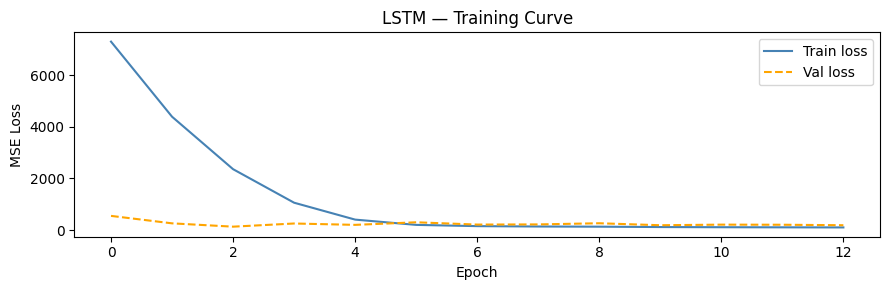

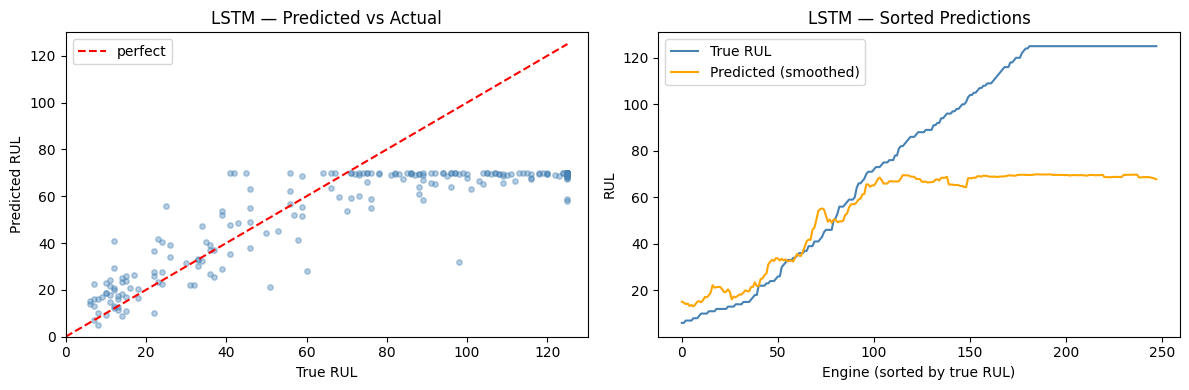

In [21]:
plot_loss_curves(train_losses, val_losses, model_name="LSTM")
plot_predictions(y_true, y_pred, model_name="LSTM")
